# 32회 ADP 복원 

# 기계학습 (60점)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

## 데이터 설명
- 데이터 출처 : https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption?resource=download 후처리
- 데이터 링크 : ./data/32/adp32_p1.csv
- 데이터 설명 : 시간대별 발전량에 대한 데이터이다


In [5]:
d1= pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_p1.csv')
display(d1.head())
d1.info()

,date,Kwh,LaCR,LeCR,co2,LaF,LeF
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    35040 non-null  object 
 1   Kwh     35040 non-null  float64
 2   LaCR    35040 non-null  float64
 3   LeCR    35040 non-null  float64
 4   co2     35040 non-null  float64
 5   LaF     35040 non-null  float64
 6   LeF     35040 non-null  float64
dtypes: float64(6), object(1)
memory usage: 1.9+ MB


In [6]:
d1.isna().mean()

date    0.0
Kwh     0.0
LaCR    0.0
LeCR    0.0
co2     0.0
LaF     0.0
LeF     0.0
dtype: float64

## 전처리 규칙
- 파생변수 ind11칼럼의 값이 1인 데이터만 훈련에 사용할 것, ind22칼럼의 값이 1인 데이터만 테스트에 사용할 것
- 모든 모델링은 그리드서치를 통해서 최적 파라미터를 산출할 것 (각 모델의 파라미터는 3개 이하로)

## 1-1  date 컬럼을 이용하여 3개의 파생변수를 만들어라
- 1. month : 해당 시각의 월 정보
- 2. day : 해당 시각의 일자 정보, 일요일-0, 월요일-1 ~ 토요일-6
- 3. nsd : 해당 시각의 일자의 자정으로부터 소요된 총 분(minute)

In [7]:
d1['date'] = pd.to_datetime(d1['date'])
d1['month'] = d1['date'].dt.month
#weekday는 월0, 일 6
d1['day'] = (d1['date'].dt.weekday + 1) % 7
d1['nsd'] = (d1['date'] - d1['date'].dt.normalize()).dt.total_seconds()/60

In [8]:
d1.head()

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15.0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30.0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45.0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60.0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75.0


## 1-2 아래 기준으로 두개의 파생변수를 추가하라
- 파생변수명(ind11) : month, day, nsd 컬럼의 합이 11의 배수이고 22의 배수가 아니라면 1의 값 그 외는 0의 값
- 파생변수명(ind22) : month, day, nsd 컬럼의 합이 22의 배수라면 1의 값 그 외는 0의 값

In [9]:
cond1 = ((d1['month']+d1['day']+d1['nsd']) % 11 == 0) & ((d1['month']+d1['day']+d1['nsd']) % 22 != 0)
cond2 = ((d1['month']+d1['day']+d1['nsd']) % 22 == 0)

d1['ind11'] = np.where(cond1, 1, 0)
d1['ind22'] = np.where(cond2, 1, 0)

d1.head()

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd,ind11,ind22
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15.0,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30.0,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45.0,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60.0,0,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75.0,1,0


In [10]:
d1[['ind11', 'ind22']].value_counts()

ind11  ind22
0      0        32259
       1         1398
1      0         1383
dtype: int64

## 1-3 아래 기준으로 한개의 파생변수를 추가하라
- 파생변수명(Kwh8) : Kwh컬럼의 값이 4.1 초과일 경우 1 그 외 0

In [11]:
d1['kwh8'] = np.where(d1['Kwh']>4.1, 1, 0)
d1['kwh8'].value_counts()

1    18815
0    16225
Name: kwh8, dtype: int64

## 1-4 전처리 완료한 데이터를 기준으로 EDA를 실시하라 (시각화 포함)

In [12]:
c_cols = ['day', 'month', 'ind11', 'ind22', 'kwh8']
d1[c_cols] = d1[c_cols].astype('O')

연속형 변수 통계량 및 시각화


,count,mean,std,min,25%,50%,75%,max
Kwh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
LaCR,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
LeCR,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
co2,35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
LaF,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
LeF,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
nsd,35040.0,712.500000,415.675572,0.0,356.25,712.50,1068.7500,1425.00


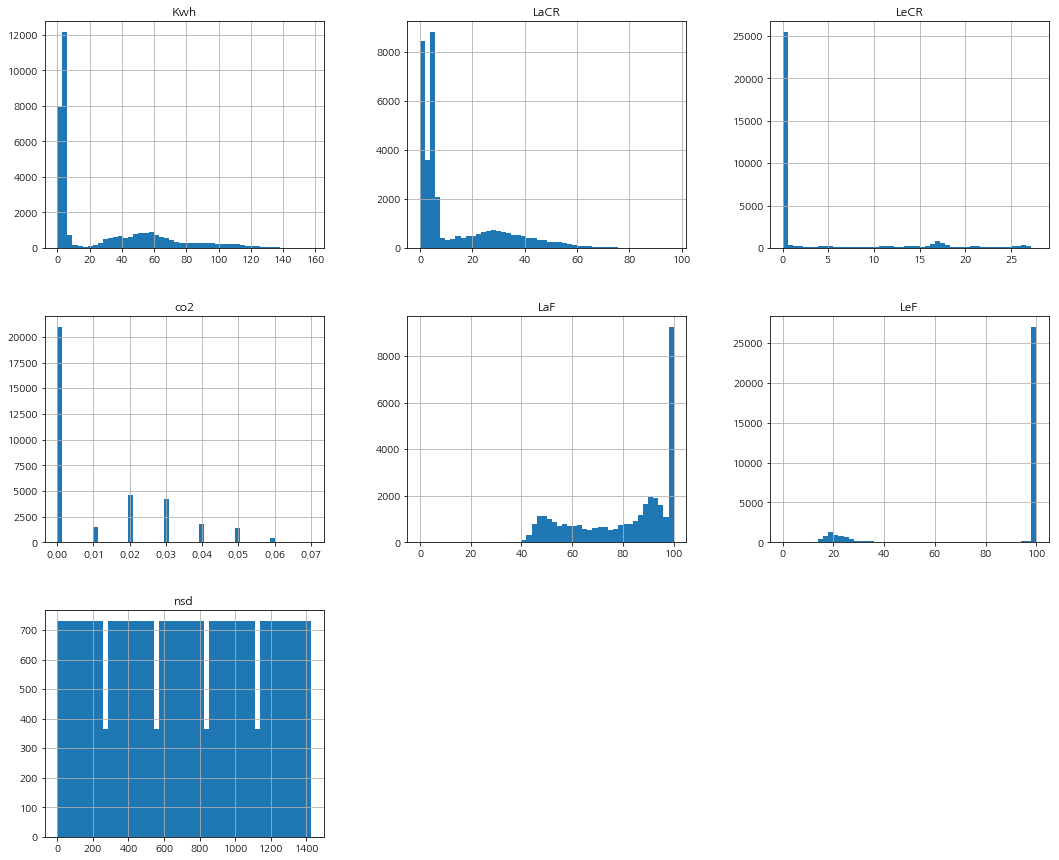

명목형 변수 통계량 및 시각화


,count,unique,top,freq
month,35040,12,12,2976
day,35040,7,1,5088
ind11,35040,2,0,33657
ind22,35040,2,0,33642
kwh8,35040,2,1,18815


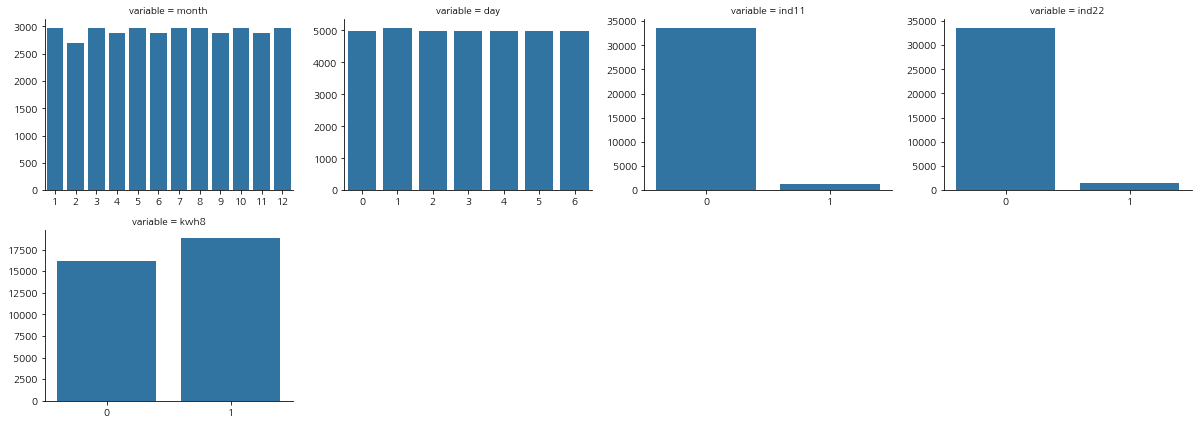

In [13]:
n_cols = d1.select_dtypes('number').columns
c_cols = d1.select_dtypes('O').columns
print("연속형 변수 통계량 및 시각화")
display(d1[n_cols].describe().T)
d1[n_cols].hist(figsize=(18, 15), bins=50, layout=(3, 3))
plt.show()

print("명목형 변수 통계량 및 시각화")
display(d1[c_cols].describe().T)
mt = d1[c_cols].melt()
g = sns.FacetGrid(mt, col='variable', col_wrap=4, height=3, aspect=1.4, sharex=False, sharey=False)
g.map_dataframe(sns.countplot, x='value')
plt.tight_layout()
plt.show()

모두 연속형 변수이며, 결측치는 없다.     
kwh, lacr, lecr, lef는 우측 긴꼬리로 양의 왜도를 띈다.(로그화 고려)  
co2(이산화탄소)는 0인 경우가 가장 많으며, 0.07값이 가장 적다.   
laf는 음의 왜도(좌측 긴꼬리)를 가진다.  
lef는 100(최대값)인 경우가 가장 많다.   
ind11, 22는 0값이 1에 비해 확연이 커서 불균형 데이터이다.  
kwh8(4.1 초과 발전량) 1인 경우가 0에 비해 다소 많은 빈도를 가진다.  



In [14]:
from sklearn.preprocessing import PowerTransformer

t_c = ['LaF', 'LeF']
l_c = ['LaCR', 'LeCR', 'co2']

yeo = PowerTransformer(method='yeo-johnson')
d1[t_c] = yeo.fit_transform(d1[t_c])

d1[l_c] = np.log1p(d1[l_c])

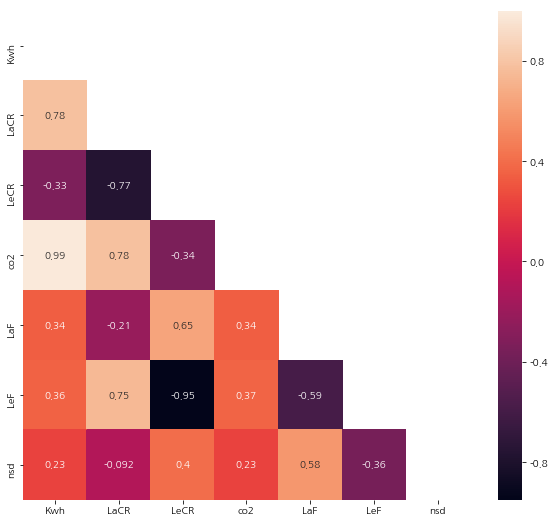

In [15]:
corr = d1.corr()
plt.figure(figsize=(10, 9))
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

피어슨 선형상관관계 결과, 비교적 높은 상관관계가 식별된다.  
lacr-co2 0.89 등 상당 수준의 양/음 상관관계가 식별되어  
다중공선성이 의심된다. 다중공선성의 정확한 진단을 위해 vif를 확인한다.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
name = d1.select_dtypes('number').columns
vif['name'] = name
vif['vif'] = [variance_inflation_factor(d1[name].values, i) for i in range(len(name))]
display(vif)

,name,vif
0,Kwh,75.506689
1,LaCR,16.990968
2,LeCR,10.362144
3,co2,63.785880
4,LaF,5.004519
5,LeF,9.163141
6,nsd,5.601841


두 변수를 제거함으로써 다중공선성이 다소 완화되었만 일부 변수에서 vif 10이상의 값이 관찰된다. 다중공선성 제거를 위한 PCA 등의 방식이 고려된다.

## 1-5 Kwh8를 종속 변수로 하여(Kwh제거) 분류 모델을 학습하고 평가하라. 서포트벡터머신과 랜덤포레스트를 사용하라. confusionmatrix를 해석하라

파생변수 ind11칼럼의 값이 1인 데이터만 훈련에 사용할 것, ind22칼럼의 값이 1인 데이터만 테스트에 사용할 것
모든 모델링은 그리드서치를 통해서 최적 파라미터를 산출할 것 (각 모델의 파라미터는 3개 이하로)

(1383, 13) (1398, 13)
- 랜덤포레스트 best param: {'cl__ccp_alpha': 0.018000000000000002, 'cl__criterion': 'entropy', 'cl__max_depth': 4}
- 랜덤포레스트 best score: 0.8351462355464868
confusion matrix


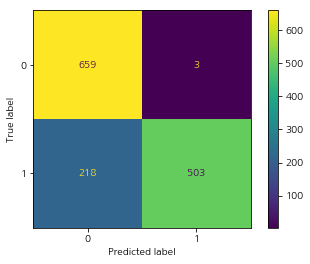

confusion matrix


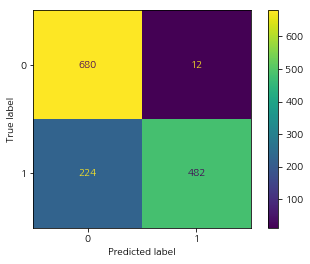

- svm classifer best param: {'cl__C': 0.01, 'cl__kernel': 'rbf'}
- svm classifer best score: 0.8387641919112646
confusion matrix


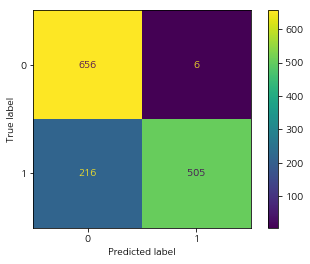

confusion matrix


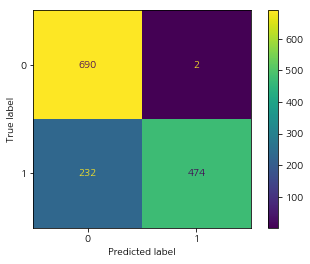

,name,data,acc,f1,recall
0,랜덤포레스트,train,0.840202,0.819886,0.697642
1,랜덤포레스트,test,0.831187,0.803333,0.682720
2,svm classifer,train,0.839479,0.819805,0.700416
3,svm classifer,test,0.832618,0.802030,0.671388


In [26]:
train = d1[d1['ind11'] == 1]
test = d1[d1['ind22'] == 1]

print(train.shape, test.shape)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, recall_score

train_X, train_Y = train.drop(['kwh8', 'date', 'Kwh'], axis=1), train['kwh8'].astype('int')
test_X, test_Y = test.drop(['kwh8', 'date', 'Kwh'], axis=1), test['kwh8'].astype('int')

n_cols = train_X.select_dtypes('number').columns
c_cols = train_X.select_dtypes('O').columns

pre_pro = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf = Pipeline([
    ('preprocess', pre_pro), 
    ('cl', RandomForestClassifier(random_state=42))
])

svc = Pipeline([
    ('preprocess', pre_pro), 
    ('cl', SVC(probability=True, random_state=42))
])


param1 = {'cl__max_depth':np.arange(3, 6), 
         'cl__ccp_alpha': np.arange(0, 0.02, 0.001), 
         'cl__criterion': ['gini', 'entropy']}

param2 = {'cl__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 
         'cl__kernel':['rbf', 'linear', 'sigmoid']}

rf_sh = GridSearchCV(
    estimator = rf, 
    param_grid = param1, 
    cv = 5,
    scoring = 'accuracy'
)

svm_sh = GridSearchCV(
    estimator = svc, 
    param_grid = param2, 
    cv = 5,
    scoring = 'accuracy'
)

model_list = [('랜덤포레스트', rf_sh), ("svm classifer", svm_sh)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'acc', 'f1', 'recall'])

for m_name, model in model_list:
    model.fit(train_X, train_Y)
    print(f"- {m_name} best param: {model.best_params_}")
    print(f"- {m_name} best score: {model.best_score_}")
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred)
        recall = recall_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, acc, f1, recall]
        print(f"confusion matrix")
        cm = confusion_matrix(y, pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()
display(rs)

그리드 서치 5-fold 학습결과 최적의 모델 파라미터를 도출하여 분류성능을 accuracy와 f1 score로 비교하였다.  

- 랜덤포레스트 best param: {'cl__ccp_alpha': 0.018000000000000002, 'cl__criterion': 'entropy', 'cl__max_depth': 4}
- 랜덤포레스트 best score: 0.8351462355464868
- svm classifer best param:{'cl__C': 0.01, 'cl__kernel': 'rbf'}
- svm classifer best score: 0.8387641919112646

두 모델 학습 결과 accuracy는 0.8이상이며, train/test set 성능이 비슷하여 과적합은 없었다.  
test set 기준 accuracy는 비슷한 수준이며, recall이 0.682720로 나은 성능인 랜덤포레스트 분류모델을 채택한다. 

모델의 accuracy는 0.8이상으로 준수한 성능을 보이나, 실제 1라벨을 0으로 오분류한 비율이 높음을 알 수 있다.(recall이 낮음)

## 1-6 Kwh를 종속 변수로 하여(Kwh8 제거) 회귀 모델을 학습하고 평가하라. 서포트벡터머신과 랜덤포레스트를 사용하라

In [27]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

train_X, train_Y = train.drop(['kwh8', 'date', 'Kwh'], axis=1), train['Kwh'].astype('int')
test_X, test_Y = test.drop(['kwh8', 'date', 'Kwh'], axis=1), test['Kwh'].astype('int')

n_cols = train_X.select_dtypes('number').columns
c_cols = train_X.select_dtypes('O').columns

pre_pro = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf_r = Pipeline([
    ('preprocess', pre_pro), 
    ('lg', RandomForestRegressor(random_state=42))
])

svr = Pipeline([
    ('preprocess', pre_pro), 
    ('lg', SVR())
])


param1 = {'lg__max_depth':np.arange(3, 6), 
         'lg__ccp_alpha': np.arange(0, 0.02, 0.001), 
         'lg__min_samples_split': np.arange(2, 6)}

param2 = {'lg__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 
         'lg__kernel':['rbf', 'linear', 'sigmoid']}

rf_sh2 = GridSearchCV(
    estimator = rf_r, 
    param_grid = param1, 
    cv = 5,
    scoring = 'neg_mean_squared_error'
)

svm_sh2 = GridSearchCV(
    estimator = svr, 
    param_grid = param2, 
    cv = 5,
    scoring = 'neg_mean_squared_error'
)

model_list = [('랜덤포레스트', rf_sh2), ("svm regressor", svm_sh2)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'r2', 'rmse'])

for m_name, model in model_list:
    model.fit(train_X, train_Y)
    print(f"- {m_name} best param: {model.best_params_}")
    print(f"- {m_name} best score: {model.best_score_}")
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        rmse = np.sqrt(mean_squared_error(y, pred))
        r2 = r2_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, r2, rmse]
display(rs)

- 랜덤포레스트 best param: {'lg__ccp_alpha': 0.006, 'lg__max_depth': 5, 'lg__min_samples_split': 4}
- 랜덤포레스트 best score: -35.286950579503014
- svm regressor best param: {'lg__C': 100, 'lg__kernel': 'rbf'}
- svm regressor best score: -37.76577377130217


,name,data,r2,rmse
0,랜덤포레스트,train,0.982282,4.338985
1,랜덤포레스트,test,0.973531,5.398415
2,svm regressor,train,0.983822,4.146212
3,svm regressor,test,0.883250,11.337665


그리드 서치 5-fold로 찾은 최적의 하이퍼 파라미터 및 score는 다음과 같다.  
- 랜덤포레스트 best param: 'lg__ccp_alpha': 0.006, 'lg__max_depth': 5, 'lg__min_samples_split': 4
- 랜덤포레스트 best score: -35.28808983334858
- svm classifer best param: {'lg__C': 100, 'lg__kernel': 'rbf'}
- svm classifer best score: -37.76577377130217

svm 회귀모델의 경우 과적합이 보이며, 랜덤포레스트 회귀모형의 성능이 더 뛰어남을 알 수 있다.  

랜덤포레스트	r2 설명력(분산의 약 97%를 설명)(0.973531), rsme(5.398415)

## 1-7 아래 두 조건으로 각각 데이터를 추출하여 회귀 모델링을 하고 1-6과 성능을 비교하라
- Kwh8 값이 1인 데이터만 추출 후 Kwh8 컬럼 제거
- Kwh8 값이 0인 데이터만 추출 후 Kwh8 컬럼 제거

In [28]:
# Kwh8 값이 1인 데이터만 추출 후 Kwh8 컬럼 제거

train1 = d1[(d1['ind11'] == 1) & (d1['kwh8'] == 1)]
test1 = d1[(d1['ind22'] == 1) & (d1['kwh8'] == 1)]

# Kwh8 값이 0인 데이터만 추출 후 Kwh8 컬럼 제거
train2 = d1[(d1['ind11'] == 1) & (d1['kwh8'] == 0)]
test2 = d1[(d1['ind22'] == 1) & (d1['kwh8'] == 0)]

def check(train, test):
    train_X, train_Y = train.drop(['kwh8', 'date', 'Kwh'], axis=1), train['Kwh'].astype('int')
    test_X, test_Y = test.drop(['kwh8', 'date', 'Kwh'], axis=1), test['Kwh'].astype('int')

    model_list = [('랜덤포레스트', rf_sh2), ("svm regressor", svm_sh2)]
    dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

    rs = pd.DataFrame(columns=['name', 'data', 'r2', 'rmse'])

    for m_name, model in model_list:
        model.fit(train_X, train_Y)
        print(f"- {m_name} best param: {model.best_params_}")
        print(f"- {m_name} best score: {model.best_score_}")
        for d_name, x, y in dt_list:
            pred = model.predict(x)
            rmse = np.sqrt(mean_squared_error(y, pred))
            r2 = r2_score(y, pred)
            rs.loc[len(rs)] = [m_name, d_name, r2, rmse]
    display(rs)
print("<<Kwh8 값이 1인 데이터만 추출 후 Kwh8 컬럼 제거>>")
check(train1, test1)
print("<<Kwh8 값이 0인 데이터만 추출 후 Kwh8 컬럼 제거>>")
check(train2, test2)

<<Kwh8 값이 1인 데이터만 추출 후 Kwh8 컬럼 제거>>
- 랜덤포레스트 best param: {'lg__ccp_alpha': 0.0, 'lg__max_depth': 5, 'lg__min_samples_split': 3}
- 랜덤포레스트 best score: -83.68644471710584
- svm regressor best param: {'lg__C': 100, 'lg__kernel': 'rbf'}
- svm regressor best score: -80.47460757947307


,name,data,r2,rmse
0,랜덤포레스트,train,0.956465,7.022377
1,랜덤포레스트,test,0.939682,8.661284
2,svm regressor,train,0.967963,6.024073
3,svm regressor,test,0.889726,11.711024


<<Kwh8 값이 0인 데이터만 추출 후 Kwh8 컬럼 제거>>
- 랜덤포레스트 best param: {'lg__ccp_alpha': 0.005, 'lg__max_depth': 4, 'lg__min_samples_split': 2}
- 랜덤포레스트 best score: -0.2835214800079346
- svm regressor best param: {'lg__C': 0.1, 'lg__kernel': 'sigmoid'}
- svm regressor best score: -0.31635360967617177


,name,data,r2,rmse
0,랜덤포레스트,train,0.206944,0.476003
1,랜덤포레스트,test,0.172692,0.498995
2,svm regressor,train,-0.064193,0.551402
3,svm regressor,test,-0.420640,0.653889


두 조건에서 회귀모형을 학습하였다.  
첫번째 조건인 Kwh8 값이 1인 데이터만 추출 후 Kwh8 컬럼 제거는 1-6의 결과와 비교 시 약간의 성능저하가 식별된다.

하지만 두 번째 조건인 Kwh8 값이 0인 데이터만 추출 후 Kwh8 컬럼 제거에서 획기적으로 rmse 성능이 향상된 것을 알 수 있는데   
(랜덤포레스트: 5.398428 -> 0.498256)
이는 앞서 1-5의 분류모형과도 연관이 있다.  
분류모형에서 kwh8 label 0은 잘 분류하였으며, 1은 0으로 오분류한 비율이 많음을 확인하였는데  
label 0을 분류하는 특징이 뚜렷하기 때문에 회귀 문제에서도 상대적으로 균질하고 예측하기 수월한 분포를 가진다고 해석할 수 있음  

두 가지 조건으로 나누어 회귀모형을 학습한 결과는 다음과 같은 시사점을 줍니다.

첫째, Kwh8 = 1인 데이터만 추출하고 Kwh8 컬럼을 제거하여 학습했을 때는   
전체 데이터(1–6 조건)와 비교해 성능 차이가 거의 없었습니다.  
즉, 이 서브셋에서는 Kwh8 특성이 예측력에 크게 기여하지 않았습니다.

반면, Kwh8 = 0인 데이터만 사용했을 때는 RMSE가 랜덤포레스트: 5.224 → 0.482 로 획기적으로 개선되었습니다.
이 현상은 앞서 수행한 분류모형 결과와도 연관이 깊습니다. 분류모형에서 Kwh8 레이블이 0인 샘플은 높은 정확도로 분류되었으나  
레이블 1인 샘플은 종종 0으로 오분류되는 경향을 보였습니다.

즉, Kwh8 = 0 클래스는 특징(feature) 패턴이 뚜렷하여 분류모형에서도 잘 구분되었고  
그 하위 데이터만으로 회귀모형을 학습했을 때 예측 오차가 크게 줄었다는 점에서,  
레이블 0에 속하는 데이터가 회귀 문제에서도 상대적으로 균질하고 예측하기 수월한 분포를 가진다고 해석할 수 있습니다.

## 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15126430/fileData.do 후처리 + 자체제작
- 데이터 링크 : 
    - ./adp32_p2.csv
    - ./adp32_p2_sub.csv
- 데이터 설명 : 
    - 두가지 데이터이다. 
    - adp32_p2.csv : J시의 4개의 발전기의 시간당 발전용량에 대한 정보이다.
    - adp32_p2_sub.csv : J시의 시간별 계절성 정보 데이터이다.

In [379]:
d2g=pd.read_csv('./adp32_p2.csv')
d2w= pd.read_csv('./adp32_p2_sub.csv')
display(d2g)
display(d2w)

,발전기명,일자,설비용량,0시,1시,2시,3시,4시,5시,6시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,a,2020-01-01,263.225,0.0,0.000,0.000,0.000,0.000,0.0,0.0,...,93.280,53.840,21.630,5.690,4.610,4.270,1.330,0.530,0.000,0.0
1,b,2020-01-01,245.725,0.0,0.000,0.000,0.000,0.000,0.0,0.0,...,88.250,51.059,22.283,5.244,4.183,3.848,1.290,0.564,0.000,0.0
2,c,2020-01-01,254.425,0.0,0.000,0.000,0.000,0.000,0.0,0.0,...,90.641,50.344,22.072,5.652,4.495,4.089,1.240,0.526,0.000,0.0
3,d,2020-01-01,250.125,0.0,0.000,0.000,0.000,0.000,0.0,0.0,...,86.995,51.953,21.831,6.149,4.666,4.141,1.228,0.491,0.000,0.0
4,a,2020-01-02,263.225,0.0,0.000,0.000,0.000,0.000,0.0,0.0,...,39.000,25.860,8.310,4.090,0.730,1.070,0.390,0.020,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4375,d,2022-12-30,384.021,0.0,0.207,0.166,0.041,0.011,0.0,0.0,...,80.700,63.235,25.996,6.441,3.961,4.076,1.417,0.400,0.011,0.0
4376,a,2022-12-31,368.121,0.0,0.190,0.150,0.140,0.050,0.0,0.0,...,210.580,143.700,49.390,7.450,5.540,7.830,7.220,3.750,0.660,0.0
4377,b,2022-12-31,379.121,0.0,0.177,0.136,0.153,0.049,0.0,0.0,...,217.254,136.629,48.443,6.717,5.427,7.208,7.409,3.388,0.636,0.0
4378,c,2022-12-31,364.021,0.0,0.192,0.144,0.127,0.046,0.0,0.0,...,192.580,138.849,51.343,7.671,5.825,7.840,7.684,3.874,0.635,0.0


,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량
0,2020-01-01 00:00,2.4,NaN,63.0,0.0,9,0.0,0.0
1,2020-01-01 01:00,2.6,0.0,63.0,0.0,9,0.0,0.0
2,2020-01-01 02:00,2.7,0.0,68.0,0.0,9,0.0,0.0
3,2020-01-01 03:00,3.2,0.0,69.0,0.0,9,0.0,0.0
4,2020-01-01 04:00,3.0,0.0,65.0,0.0,9,NaN,0.0
...,...,...,...,...,...,...,...,...
26275,2022-12-31 19:00,6.9,0.0,60.0,0.0,6,0.0,0.0
26276,2022-12-31 20:00,6.8,NaN,59.0,0.0,7,0.0,0.0
26277,2022-12-31 21:00,6.8,0.0,61.0,0.0,6,0.0,0.0
26278,2022-12-31 22:00,6.0,0.0,62.0,0.0,3,0.0,0.0


## 2-1 아래 조건들을 참고하여 전처리를 시행하라
- 계절성 정보 데이터 중 강수량과 일조량의 결측치를 0으로 채워라
- 계절성 정보 데이터 중 기온은 직전시간과 직후시간의 기온의 평균값으로 결측치를 대치하라
- 계절성 정보데이터와 발전용량 데이터를 머지하라.
    - 계절성 정보데이터의 일자,시각을 기준으로 한다.
    - 계절성 정보데이터에 발전기명, 설비용량, 발전량 컬럼을 추가한다.

<img src ='result.png' width='800' height='200'/>

In [380]:
d2g['일자'] = pd.to_datetime(d2g['일자']).dt.strftime('%Y-%m-%d')
d2w['일시'] = pd.to_datetime(d2w['일시'])
d2w['일자'] = d2w['일시'].dt.strftime('%Y-%m-%d')
d2w['시간'] = d2w['일시'].dt.hour.astype(int)

d2w[['강수량(mm)', '일조(hr)']] = d2w[['강수량(mm)', '일조(hr)']].fillna(0)

d2w['기온'] = d2w['기온'].fillna((d2w['기온'].shift(1)+d2w['기온'].shift(-1))/2)
d2w['기온'] = d2w['기온'].fillna(d2w['기온'].shift(-1))
d2w['기온'] = d2w['기온'].fillna((d2w['기온'].shift(1)+d2w['기온'].shift(-1))/2)                                 
print(d2w.isna().sum())

mg = d2g.melt(id_vars=['발전기명', '일자', '설비용량'], var_name='시간', value_name='발전량')
mg['시간'] = mg['시간'].str.replace('시', '').astype(int)

d2w.shape, mg.shape

일시           0
기온           0
강수량(mm)      0
습도           0
적설(cm)       0
전운량(10분위)    0
일조(hr)       0
일사량          0
일자           0
시간           0
dtype: int64


((26280, 10), (105120, 5))

In [383]:
dt = pd.merge(mg, d2w, on=['일자', '시간'], how='left').sort_values(by=['일자', '시간', '발전기명']).reset_index(drop=True)
dt.head()

,발전기명,일자,설비용량,시간,발전량,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량
0,a,2020-01-01,263.225,0,0.0,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0
1,b,2020-01-01,245.725,0,0.0,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0
2,c,2020-01-01,254.425,0,0.0,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0
3,d,2020-01-01,250.125,0,0.0,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0
4,a,2020-01-01,263.225,1,0.0,2020-01-01 01:00:00,2.6,0.0,63.0,0.0,9,0.0,0.0


In [384]:
dt.drop('일시', axis=1, inplace=True)
dt.head()

,발전기명,일자,설비용량,시간,발전량,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량
0,a,2020-01-01,263.225,0,0.0,2.4,0.0,63.0,0.0,9,0.0,0.0
1,b,2020-01-01,245.725,0,0.0,2.4,0.0,63.0,0.0,9,0.0,0.0
2,c,2020-01-01,254.425,0,0.0,2.4,0.0,63.0,0.0,9,0.0,0.0
3,d,2020-01-01,250.125,0,0.0,2.4,0.0,63.0,0.0,9,0.0,0.0
4,a,2020-01-01,263.225,1,0.0,2.6,0.0,63.0,0.0,9,0.0,0.0


## 2-2 전처리 데이터를 기준으로 아래 조건으로 train,test 데이터를 나눈다. 데이터 분리 후 train 데이터의 기초 통계량을 확인하라
- a발전기의 12시~18시의 데이터만 모델링에 사용한다. 
- 2020년도, 2021년도는 train, 2022년도는 test 데이터로 사용한다

In [386]:
data = dt[(dt['발전기명'] == 'a') & (dt['시간'].between(12, 18))]

train, test = data[data['일자'].str[:4].isin(['2020', '2021'])], data[data['일자'].str[:4] == '2022']

train.shape, test.shape

((5110, 12), (2555, 12))

## 2-3 train 데이터 세트의 발전량과 나머지 변수간의 상관관계를 확인하라


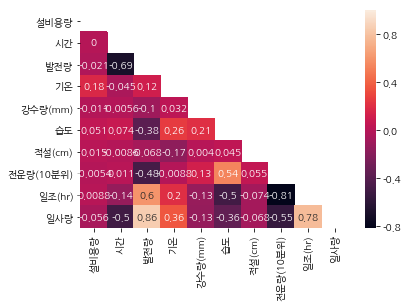

<Figure size 720x648 with 0 Axes>

In [387]:
corr = train.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.figure(figsize=(10, 9))
plt.show()

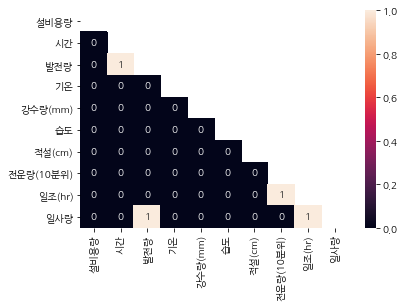

<Figure size 720x648 with 0 Axes>

In [388]:
corr = np.abs(train.corr())>0.6
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.figure(figsize=(10, 9))
plt.show()

피어슨 선형상관관계 분석결과 발전량-시간, 발전량-일사량, 일조-전운량, 일조-일사량 간  
유의미한(절대값 0.6 이상) 선형 상관관계가 식별되었다.

## 2-4 발전량을 종속변수로 하여 2개의 회귀모델링을 진행하고 모델을 평가하라

1. 랜덤포레스트 회귀 모형: 배깅기반의 앙상블 모델로 비교적 강력한 성능을 보여주며, 이상치에 강건한 특징이 있지만  
   대규모, 다차원 데이터에서 계산비용이 많이 드는 단점이 있다. 
   
2. svm regressor: 서포트 벡터를 활용한 비확률적 모델이다.   
   데이터의 특성이 적어도 복잡한 결정경계 생성이 가능하나, 스케일링 등 전처리와 매개변수 설정이 어렵고 대용량 데이터에서 계산비용이 많이 드는 단점이 있다. 
   
r2, rmse를 성능지표로 두 모델을 비교한다. 

In [389]:
train_X, train_Y = train.drop(['발전기명', '일자', '발전량'], axis=1), train['발전량']
test_X, test_Y = test.drop(['발전기명', '일자', '발전량'], axis=1), test['발전량']

n_cols = train_X.select_dtypes('number').columns
c_cols = train_X.select_dtypes('O').columns

pre_pro = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

pre_pro2 = make_column_transformer(
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf_r = Pipeline([
    ('preprocess', pre_pro2), 
    ('lg', RandomForestRegressor(random_state=42))
])

svr = Pipeline([
    ('preprocess', pre_pro), 
    ('lg', SVR())
])


param1 = {'lg__max_depth':np.arange(3, 6), 
         'lg__ccp_alpha': np.arange(0, 1, 0.1), 
         'lg__min_samples_split': np.arange(2, 6)}

param2 = {'lg__C': np.arange(0, 1, 0.1), 
         'lg__kernel':['rbf', 'linear', 'sigmoid']}

rf_sh2 = GridSearchCV(
    estimator = rf_r, 
    param_grid = param1, 
    cv = 5,
    scoring = 'neg_mean_squared_error'
)

svm_sh2 = GridSearchCV(
    estimator = svr, 
    param_grid = param2, 
    cv = 5,
    scoring = 'neg_mean_squared_error'
)

model_list = [('랜덤포레스트', rf_sh2), ("svm regressor", svm_sh2)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'r2', 'rmse'])

for m_name, model in model_list:
    model.fit(train_X, train_Y)
    print(f"- {m_name} best param: {model.best_params_}")
    print(f"- {m_name} best score: {model.best_score_}")
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        rmse = np.sqrt(mean_squared_error(y, pred))
        r2 = r2_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, r2, rmse]
display(rs)

- 랜덤포레스트 best param: {'lg__ccp_alpha': 0.4, 'lg__max_depth': 5, 'lg__min_samples_split': 2}
- 랜덤포레스트 best score: -535.9226377432105
- svm regressor best param: {'lg__C': 0.4, 'lg__kernel': 'linear'}
- svm regressor best score: -638.7039160107804


,name,data,r2,rmse
0,랜덤포레스트,train,0.902235,21.047743
1,랜덤포레스트,test,0.814924,31.692351
2,svm regressor,train,0.865597,24.678459
3,svm regressor,test,0.819271,31.318022


In [393]:
dt['발전량'].max() - dt['발전량'].min()

287.366

두 모델 학습결과이다. train/test set 모두에서 비슷한 성능을 보여주어 과적합은 없었다.  
test set 기준으로 두 성능지표를 가지고 평가했을 때 svm regressor 모형의 rmse가 31.318022로   
랜덤포레스트 회귀모델에 비해 약간 나은 성능을 보여주어 해당 모델을 채택한다.  
svm regressor 모델은 test set 기준 데이터 분산의 약 81.92%를 설명할 수 있으며,  
전체 데이터 범위(287.366) 대비 약 +- 11%의 표준편차를 가지는 모델이라고 평가할 수 있다. 

# 통계 (40점)

## 데이터 설명
- 데이터 출처 : https://www.kaggle.com/code/prasadperera/the-boston-housing-dataset 후처리
- 데이터 링크 : ./data/32/adp32_s1.csv
- 데이터 설명 : 보스턴 집값 관련 데이터
    - MEDV (집값): 종속변수

In [65]:
d3 = pd.read_csv('./adp32_s1.csv')
d3.head()

,CRIM,ZN,INDUS,CHAS,NOX,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT1,LSTAT2,MEDV
0,0.00632,18.0,2.31,0.0,0.538,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,5.0520,24.0
1,0.02731,0.0,7.07,0.0,0.469,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,9.4440,21.6
2,0.02729,0.0,7.07,0.0,0.469,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,3.8970,34.7
3,0.03237,0.0,2.18,0.0,0.458,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,2.9410,33.4
4,0.06905,0.0,2.18,0.0,0.458,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,5.4075,36.2


In [67]:
d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   AGE      506 non-null    float64
 6   DIS      506 non-null    float64
 7   RAD      506 non-null    float64
 8   TAX      506 non-null    float64
 9   PTRATIO  506 non-null    float64
 10  B        506 non-null    float64
 11  LSTAT1   506 non-null    float64
 12  LSTAT2   506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


## 3-1 기본 회귀가정을 검토하라

 해당 문제는 종속변수가 1개이며 설명변수가 다중인 다중선형회귀문제이다.  
 
 회귀모델을 사용하기 위해서는 잔차의 가정을 만족하여야 한다.  
 - 선형성: 독립변수와 종속변수 간 선형관계(잔차와 예측값의 산점도)
 - 독립성: 잔차들이 서로 독립(더빈왓슨 검정)
 - 등분산성: 모든 x값에서 잔차 분산이 동일(Breusch–Pagan 검정)
 - 정규성: 잔차가 정규 분포를 따라야 함(qq-plot, shapiro-wilk 검정)
 - 다중공선성 없음(vif 10 이상 값이 있는지 확인)
 
 회귀 기본가정을 검토하기 위해 회귀모형을 적합 후 잔차검정을 실시한다.  
 
 

In [69]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

feat_cols = d3.columns[:-1]
formula = 'MEDV ~ ' + ' + '.join(feat_cols)

model = smf.ols(formula, data=d3).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     87.03
Date:                Thu, 18 Sep 2025   Prob (F-statistic):          2.09e-118
Time:                        21:40:04   Log-Likelihood:                -1538.2
No. Observations:                 506   AIC:                             3104.
Df Residuals:                     492   BIC:                             3164.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     69.4437      3.888     17.860      0.0

<잔차검정>


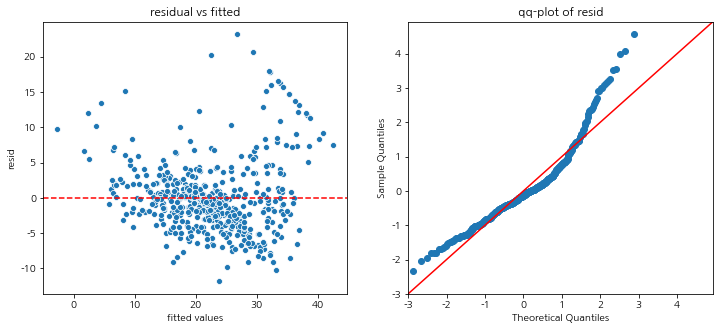

- 샤피로-윌크 정규성 검정결과: 0.000 정규성 불만족
- het_breuschpagan 검정결과: 0.000 등분산성 불만족
- 더빈왓슨 결과: 1.246


,name,vif
0,Intercept,290.729447
1,CRIM,1.830536
2,ZN,2.244940
3,INDUS,3.958267
4,CHAS,1.074816
5,NOX,4.370295
6,AGE,2.968560
7,DIS,3.895383
8,RAD,7.297913
9,TAX,8.964227


In [82]:
from scipy.stats import probplot, shapiro, levene
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import qqplot

#잔차검정
print("<잔차검정>")
fitted = model.fittedvalues
resid = model.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
#잔차와 예측값 산점도(선형성 등분산성 확인)
sns.scatterplot(x=fitted, y=resid, ax=ax[0])
ax[0].axhline(0, color='r', ls='--')
ax[0].set_xlabel('fitted values')
ax[0].set_ylabel('resid')
ax[0].set_title('residual vs fitted')

#qq plot(정규성 확인)
qqplot(resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('qq-plot of resid')
plt.show()

#shaporo-wilk 검정(정규성)
stat, p = shapiro(resid)
print(f"- 샤피로-윌크 정규성 검정결과: {p:.3f} 정규성", "만족" if p >= 0.05 else "불만족")

#등분산성 검정
bp_stat, p2, _, _ = het_breuschpagan(resid, model.model.exog)
print(f"- het_breuschpagan 검정결과: {p2:.3f} 등분산성", "만족" if p >= 0.05 else "불만족")

#독립성(자기상관)
dw = durbin_watson(resid)
print(f"- 더빈왓슨 결과: {dw:.3f}")

# 다중공선성 진단
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
name = model.model.exog_names
vif['name'] = name
vif['vif'] = [variance_inflation_factor(model.model.exog, i) for i in range(len(name))]
display(vif)

잔차 검정결과  
- 선형성: 불만족(잔차가 패턴을 그리며 무작위 분포되지 않음)
- 정규성: 불만족(qq-plot 결과 및 샤피로 윌크 테스트 결과)
- 등분산성: 불만족(잔차 산점도 상 분산이 일정하지 않으며, het_breuschpagan 검정결과 불만족)
- 독립성: 불만족(더빈왓슨 결과: 1.246로 1.5~2사이에서 벗어남)
- 다중공선성: LSTAT1, 2에서 심각한(300이상) 다중공선성 관찰

## 3-2 변수간 관계 검토하고 문제점 해결방안 2가지를 제시하라

- 우선 모델의 f통계량 p-value는 2.09e-118로 하나 이상의 회귀계수는 0이 아니라는 가정은 만족한다.  
  이 중 각 독립변수의 p-value를 보고 유의하지 않은 변수를 제거한다.  
    - INDUS     0.637058
    - AGE       0.066977
    - LSTAT1    0.328738
    - LSTAT2    0.682656
- 그 다음 심각하게 우측 긴꼬리 분포되어 있는 변수에 log화를 적용하여 분산불균형을 완화 후 다시 회귀모델 적합,   
  잔차의 기본가정을 검토한다. 
  
- 후진제거법을 적용하여, 불필요한 변수를 제거한다. 

연속형 변수 통계량 및 시각화


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677082,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000
PTRATIO,506.0,18.455534,2.164946,12.60000,17.400000,19.05000,20.200000,22.0000


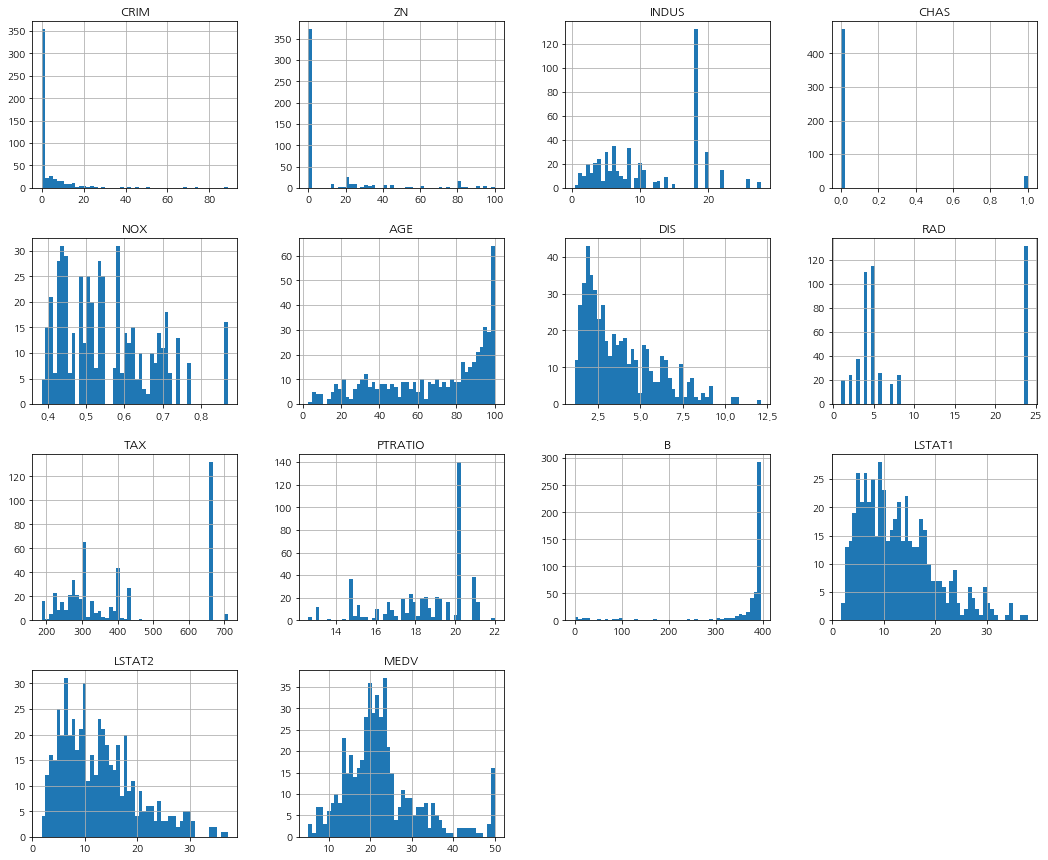

In [86]:
n_cols = d3.select_dtypes('number').columns
print("연속형 변수 통계량 및 시각화")
display(d3[n_cols].describe().T)
d3[n_cols].hist(figsize=(18, 15), bins=50, layout=(4, 4))
plt.show()

## 3-3 3-2에서 제안한 것을 반영하여 문제를 해결하고 적용 결과를 제시하라

In [106]:
#로그화
log_cols =  ['CRIM', 'ZN', 'DIS']
d3[log_cols] = np.log1p(d3[log_cols])

x = d3.drop(['MEDV', 'LSTAT1', 'LSTAT2'], axis=1)
y = d3['MEDV']

def stepwise(x, y):
    x = sm.add_constant(x)
    selected = ['const']
    all_vars = [c for c in x.columns if c != 'const']
    for _ in range(len(all_vars)):
        # Forward
        remaining = [v for v in all_vars if v not in selected]
        if remaining:
            best_aic, best_var = float('inf'), None
            for var in remaining:
                try:
                    aic = sm.OLS(y, x[selected + [var]]).fit(disp=0).aic
                    if aic < best_aic:
                        best_aic, best_var = aic, var
                except:
                    continue
            current_aic = sm.OLS(y, x[selected]).fit(disp=0).aic
            if best_aic < current_aic:
                selected.append(best_var)
        # Backward
        if len(selected) > 1:
            best_aic, worst_var = float('inf'), None
            for var in selected:
                if var == 'const':
                    continue
                try:
                    temp = [v for v in selected if v != var]
                    aic = sm.OLS(y, x[temp]).fit(disp=0).aic
                    if aic < best_aic:
                        best_aic, worst_var = aic, var
                except:
                    continue
            current_aic = sm.OLS(y, x[selected]).fit(disp=0).aic
            if best_aic < current_aic:
                selected.remove(worst_var)
    return selected, sm.OLS(y, x[selected]).fit(disp=0)

feat, model = stepwise(x, y)
print(f"선택변수: {feat}")
print(model.summary())

선택변수: ['const', 'PTRATIO', 'NOX', 'DIS', 'INDUS', 'CHAS', 'B', 'AGE', 'RAD', 'TAX']
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     52.45
Date:                Thu, 18 Sep 2025   Prob (F-statistic):           1.68e-66
Time:                        22:26:48   Log-Likelihood:                -1671.1
No. Observations:                 506   AIC:                             3362.
Df Residuals:                     496   BIC:                             3404.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

<잔차검정>


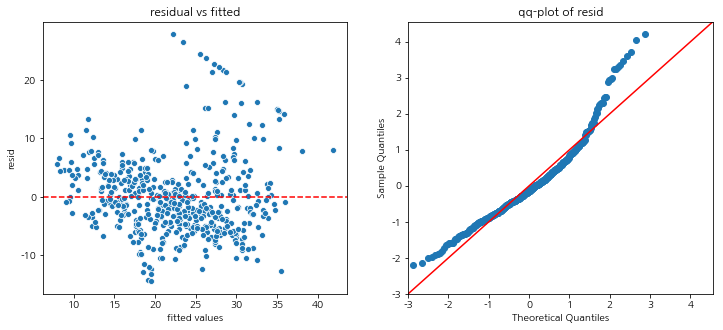

- 샤피로-윌크 정규성 검정결과: 0.000 정규성 불만족
- het_breuschpagan 검정결과: 0.000 등분산성 불만족
- 더빈왓슨 결과: 0.953


,name,vif
0,const,870.436279
1,PTRATIO,1.504764
2,NOX,4.577143
3,DIS,4.641584
4,INDUS,3.824774
5,CHAS,1.058180
6,B,1.289626
7,AGE,2.750424
8,RAD,6.700476
9,TAX,8.396841


In [107]:
#잔차검정
print("<잔차검정>")
fitted = model.fittedvalues
resid = model.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
#잔차와 예측값 산점도(선형성 등분산성 확인)
sns.scatterplot(x=fitted, y=resid, ax=ax[0])
ax[0].axhline(0, color='r', ls='--')
ax[0].set_xlabel('fitted values')
ax[0].set_ylabel('resid')
ax[0].set_title('residual vs fitted')

#qq plot(정규성 확인)
qqplot(resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('qq-plot of resid')
plt.show()

#shaporo-wilk 검정(정규성)
stat, p = shapiro(resid)
print(f"- 샤피로-윌크 정규성 검정결과: {p:.3f} 정규성", "만족" if p >= 0.05 else "불만족")

#등분산성 검정
bp_stat, p2, _, _ = het_breuschpagan(resid, model.model.exog)
print(f"- het_breuschpagan 검정결과: {p2:.3f} 등분산성", "만족" if p >= 0.05 else "불만족")

#독립성(자기상관)
dw = durbin_watson(resid)
print(f"- 더빈왓슨 결과: {dw:.3f}")

# 다중공선성 진단
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
name = model.model.exog_names
vif['name'] = name
vif['vif'] = [variance_inflation_factor(model.model.exog, i) for i in range(len(name))]
display(vif)

앞서 양의 왜도 loglp화, 다중공선성 식별 변수 삭제, 변수 선택법을 적용하였다.  
마찬가지로 정규성, 독립성, 등분산성을 만족하지 못하지만 vif가 10이상인 변수가 식별되지 않아  
다중공선성은 제거된 것을 확인할 수 있다.

## 데이터 설명
- 데이터 출처 : https://www.rdocumentation.org/packages/datasets/versions/3.6.2/topics/mtcars 후처리
- 데이터 링크 : ./adp32_s2.csv
- 데이터 설명 : 차량정보데이터

## 4-1 cyl랑 gear 컬럼으로 교차테이블을 만들어라

In [20]:
d4= pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_s2.csv')
d4.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [21]:
d4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [22]:
cr = pd.crosstab(d4['cyl'], d4['gear'])
display(cr)

gear,3,4,5
cyl,,,
4,1,8,2
6,2,4,1
8,12,0,2


## 4-2 두 범주형 변수간 차이가 존재하는지 확인하려한다. 귀무가설과 대립가설을 작성하라

한 모집단의 두 범주형 변수의 차이가 존재하는지(연관성이 있는지 독립인지) 알아보기 위해 카이제곱 독립성 검정을 실시한다.  
가설 수립 후 유의확률 5% 하 검정을 실시한다.  

<가설수립>  
- 귀무가설: 기어와 실린더 간 독립이다.(차이가 없다.)
- 대립가설: 적어도 한 그룹의 기어와 실린더 사이에는 유의미한 차이가 존재한다. 

## 4-3 통계검정을 실시하고 해석하라

In [112]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

stat, p, ddof, expected = chi2_contingency(cr)
v = association(cr, method='cramer')

print(f"카이제곱 통계량: {stat:.3f} / p-value: {p:.3f}")
print(f"크레이머 v : {v:.3f}")

카이제곱 통계량: 18.036 / p-value: 0.001
크레이머 v : 0.531


유의수준 5% 하 p-value 가 0.001로 0.05보다 작으므로 귀무가설을 기각한다.  
따라서 기어와 실린더 사이에는 유의미한 차이가 존재한다.  
크레이머 v값이 0.531로 상당한 연관성이 있는 것을 알 수 있다. 

## 데이터 설명
- 데이터 출처 : 자체제작
- 데이터 링크 : ./adp32_s3.csv
- 데이터 설명 : 남녀 급여 데이터

## 5-1 각 성별의 급여 데이터가 정규성을 만족하는지 확인하라. 

In [113]:
d5= pd.read_csv('./adp32_s3.csv')
d5.head()

,성별,급여
0,남,388.202617
1,남,320.007860
2,남,348.936899
3,남,412.044660
4,남,393.377900


In [116]:
gr = [(name, g['급여']) for name, g in d5.groupby('성별')]
for name, g in gr:
    stat, p = shapiro(g)
    print(f"- {name} 통계량: {stat:.3f} / p-value: {p:.3f}")

- 남 통계량: 0.960 / p-value: 0.406
- 여 통계량: 0.688 / p-value: 0.000


 각 성별의 급여데이터가 정규성을 만족하는지 확인하기 위해 shaprio wilk 검정을 실시한다.   
남성그룹은 p-value가 0.406으로 귀무가설을 기각할 수 없어 정규성을 만족하며, 여성그룹은 귀무가설을 기각하여 정규성을 만족하지 않는다.

## 5-2 위 결과에 맞는 남녀 월급 차이가 있는지 확인 하기 위한 검정 전략을 설명하라

여성그룹이 정규성을 만족하지 않으므로 모수검정을 실시할 수 없다.  
독립검정 ttest에 대응되는 비모수검정 기법인 맨위트니-u 검정을 실시한다.  
유의수준 5% 하에서 다음과 같은 가설을 수립 후 검정을 실시한다.   
- 귀무가설: 남녀 월급차이가 없다. 
- 대립가설: 남녀 월급차이가 있다.

## 5-3 가설에 따른 검정을 수행하고, 검정통계량과 p-value를 설명하라

In [119]:
from scipy.stats import mannwhitneyu

mstat, p = mannwhitneyu(gr[0][1], gr[1][1])
print(f"- 맨위트니 u검정 통계량: {mstat:.3f} / p-value: {p:.3f}")

- 맨위트니 u검정 통계량: 586.000 / p-value: 0.000


유의수준 5% 하 귀무가설을 기각할 수 있으므로 남녀 월급차이가 있다는 대립가설은 통계적으로 유의하다.